In this homework, you are going to use the code from TrafficSignsClassification notebook and create your own traffic sign classifier.

In [1]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

Use the data from data/subset_homework folder and visualize some examples. How many images are there for each class?

Num samples class_0 2220
Num samples class_1 2250

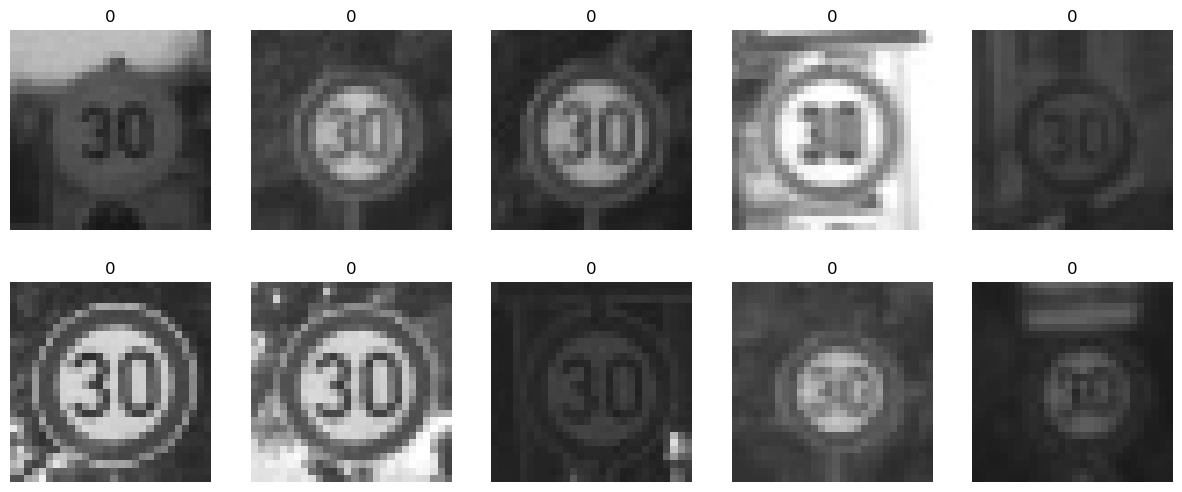

In [2]:
folder = 'subset_homework'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

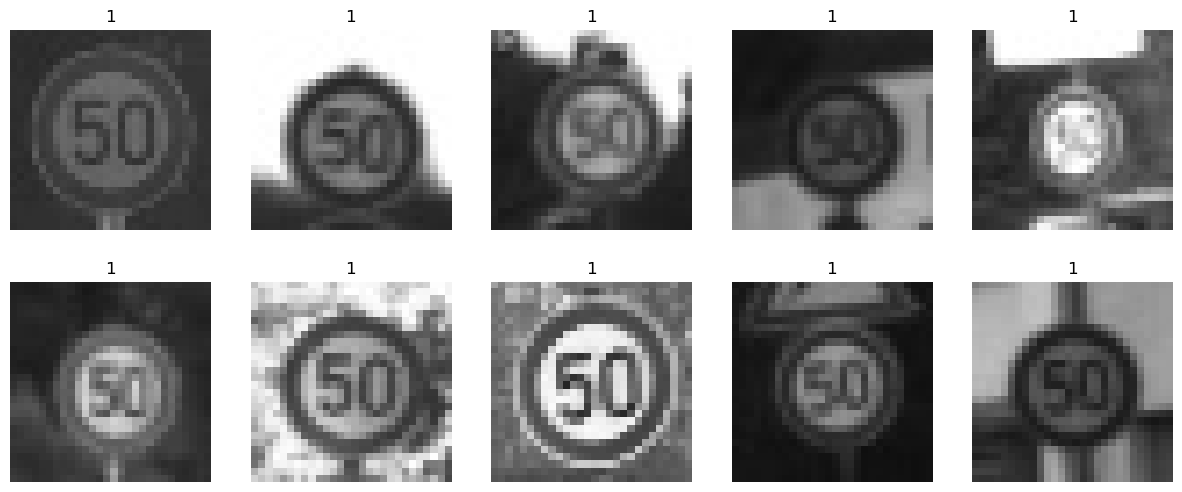

In [3]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [4]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


#### Prepare Input Data

To train our neural network model, we have to prepare the data to the format the the model actually expects. In our case, this will be numpy arrays.

In [5]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


But now we have a problem. We cannot just feed the image to a neuron since the neuron inputs are flat (one dimensional). On the other hand, the images are 2D matrices. Therefore, we need to "flatten" the images to a one dimensional vector of pixels.

In [6]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.01545095443725586


Before the training, let's again have a look at some raqndom samples from our dataset.

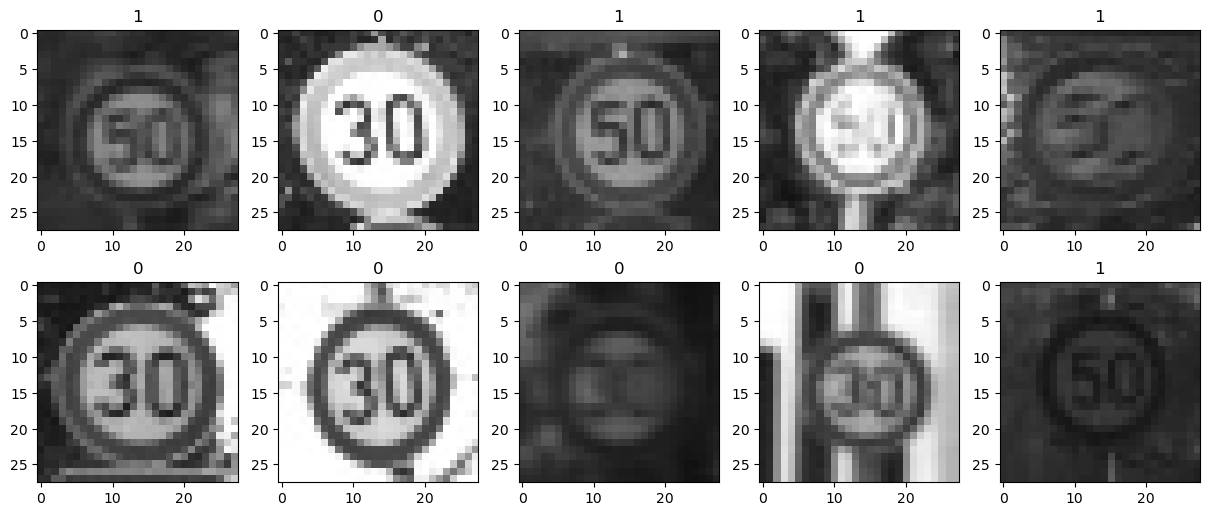

In [7]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

In [8]:
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

2.20.0


The following network will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

In [9]:
inputs = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             785 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

Before starting the training, we have to compile the model. During the compilation, we indicate what optimizer we want to use and what loss should be applied for the minimization process.

In [10]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

And let's train :-)

In [11]:
history = model.fit(pixels, labels, epochs=30, batch_size=32)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3003
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2295
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1903
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1615
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1436
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1287
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1198
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1107  
Epoch 9/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1049
Epoch 10/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1001
Epoch 11/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0967
Epoch 12/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0959  
Epoch 13/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0928  
Epoch 14/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0887
Epoch 15/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

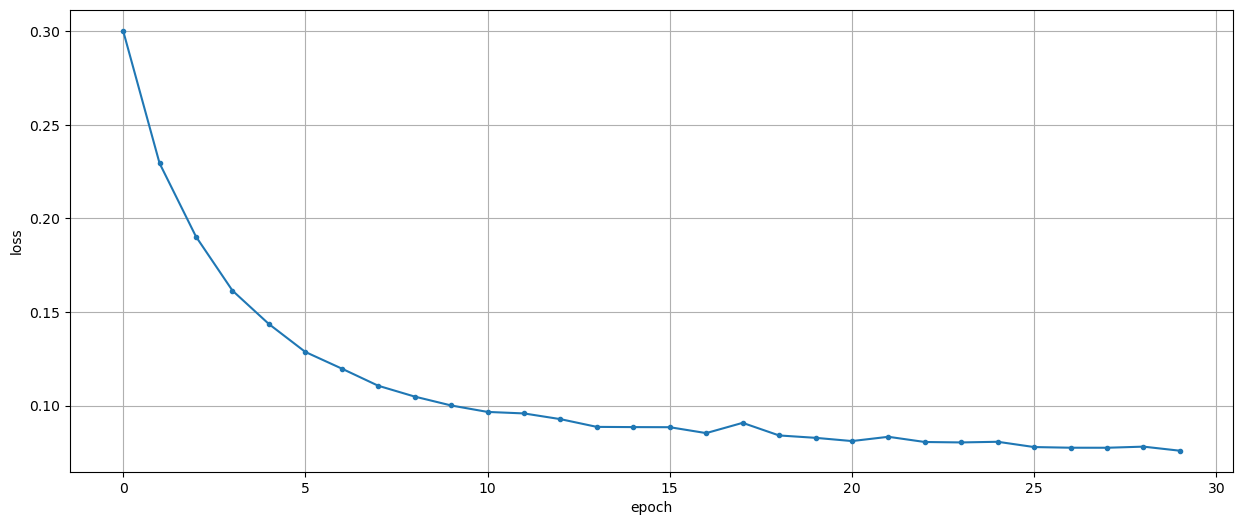

In [12]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[0.53858334] [0.53858334]


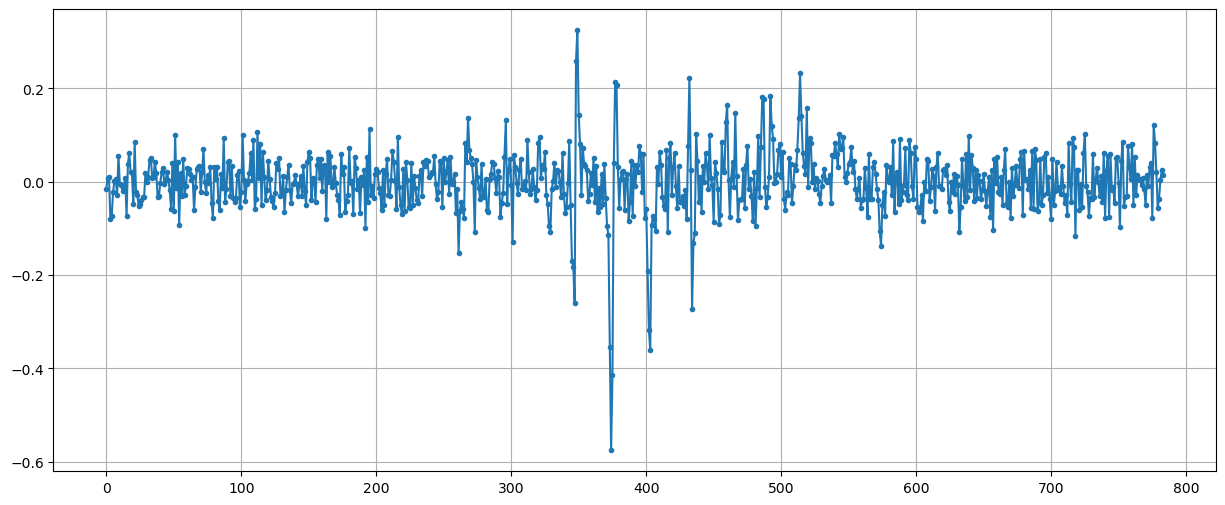

In [13]:
# Let's also have a looks at the learnt weights
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

#### Performance Evaluation

Once our model is trained, we will can run it on our images to see how it performs (inference).

In [14]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[[0.02176994]] 0


In [15]:
# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step


In [16]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9449664429530201


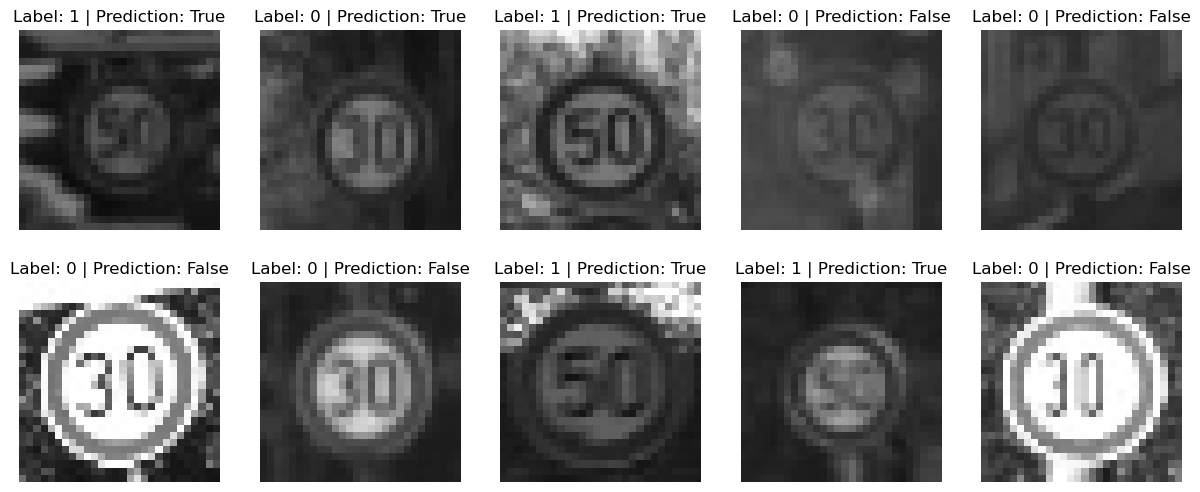

In [17]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)

Lets try one more hidden layer and different activation function

In [18]:
print(pixels.shape[1])
print(inputs)

784
<KerasTensor shape=(None, 784), dtype=float32, sparse=False, ragged=False, name=keras_tensor>


In [19]:
hidden_neurons = 128

# Define the Sequential model
model1 = Sequential([
    # Layer 1: The Hidden Layer
    # input_shape is set to (784,) — the comma is crucial!
    Dense(units=hidden_neurons, activation='relu', input_shape=(pixels.shape[1],)),
   
    # Layer 2: The Output Layer
    # The output units depend on the task (1 for binary/regression).
    Dense(units=1, activation='sigmoid') 
])

model1.summary()

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model1.compile(optimizer ='adam', loss = 'mean_squared_error')
history = model1.fit(pixels, labels, epochs=30, batch_size=32)


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2143
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1540
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1146
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0944
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0820
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0700
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0603
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0580
Epoch 9/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0552
Epoch 10/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0496
Epoch 11/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0486
Epoch 12/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0441
Epoch 13/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0435
Epoch 14/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0436
Epoch 15/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

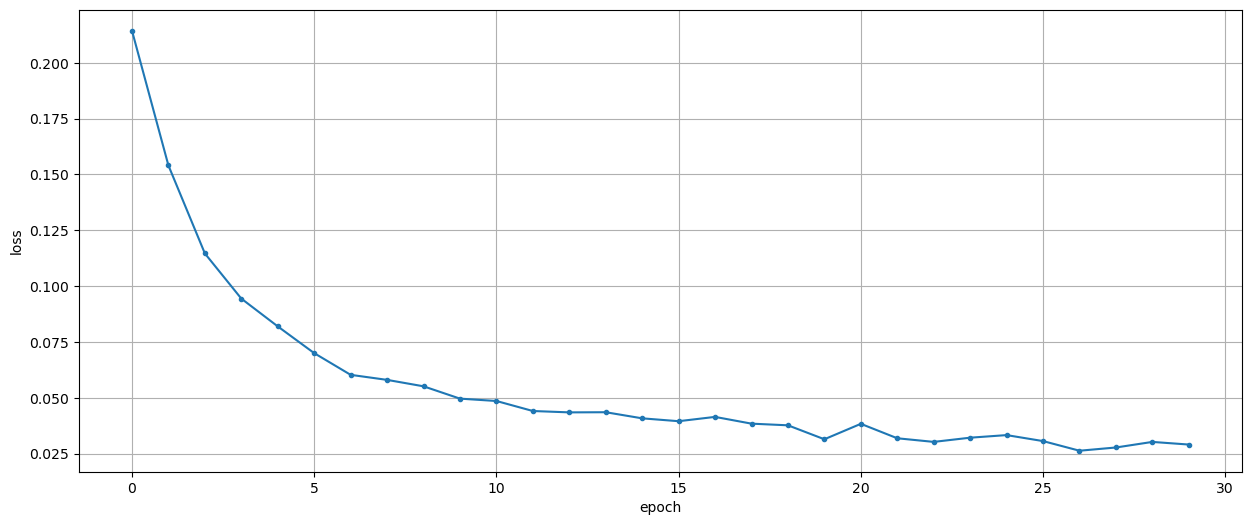

In [21]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

In [22]:
idx = 50
pred = model1.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])
# Run it on the entire dataset
predictions = model1.predict(pixels).squeeze()
predictions = predictions > 0.5
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[0.0008908]] 0
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step
Accuracy 0.9543624161073826
